# ANN based classification with pytorch

In this notebook, we will work through setting up a model and running a classification fit on the weather dataset. For more details, see
https://zenodo.org/records/5071376

In [1]:
import pandas as pd

data = pd.read_csv("https://zenodo.org/record/5071376/files/weather_prediction_dataset_light.csv?download=1")

In [2]:
data.columns

Index(['DATE', 'MONTH', 'BASEL_cloud_cover', 'BASEL_humidity',
       'BASEL_pressure', 'BASEL_global_radiation', 'BASEL_precipitation',
       'BASEL_sunshine', 'BASEL_temp_mean', 'BASEL_temp_min', 'BASEL_temp_max',
       'DE_BILT_cloud_cover', 'DE_BILT_humidity', 'DE_BILT_pressure',
       'DE_BILT_global_radiation', 'DE_BILT_precipitation', 'DE_BILT_sunshine',
       'DE_BILT_temp_mean', 'DE_BILT_temp_min', 'DE_BILT_temp_max',
       'DRESDEN_cloud_cover', 'DRESDEN_humidity', 'DRESDEN_global_radiation',
       'DRESDEN_precipitation', 'DRESDEN_sunshine', 'DRESDEN_temp_mean',
       'DRESDEN_temp_min', 'DRESDEN_temp_max', 'DUSSELDORF_cloud_cover',
       'DUSSELDORF_humidity', 'DUSSELDORF_pressure',
       'DUSSELDORF_global_radiation', 'DUSSELDORF_precipitation',
       'DUSSELDORF_sunshine', 'DUSSELDORF_temp_mean', 'DUSSELDORF_temp_min',
       'DUSSELDORF_temp_max', 'HEATHROW_cloud_cover', 'HEATHROW_humidity',
       'HEATHROW_pressure', 'HEATHROW_global_radiation',
       'HEATH

In [3]:
data.shape

(3654, 91)

In [4]:
nr_rows = 3*365

X_data = data.loc[:nr_rows]
X_data = X_data.drop(columns=['DATE', 'MONTH'])

## Creating a Classification Dataset

In [5]:
import numpy as np

y_data_ = data.loc[1:(nr_rows+1)]["BASEL_sunshine"]
y_data = (y_data_ > 5).astype(np.int32)

In [6]:
X_data.describe()

,BASEL_cloud_cover,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,BASEL_temp_max,DE_BILT_cloud_cover,...,SONNBLICK_temp_mean,SONNBLICK_temp_min,SONNBLICK_temp_max,TOURS_humidity,TOURS_pressure,TOURS_global_radiation,TOURS_precipitation,TOURS_temp_mean,TOURS_temp_min,TOURS_temp_max
count,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000,...,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000
mean,5.540146,0.754991,1.017604,1.280265,0.259735,4.527646,11.230201,7.281478,15.628285,5.693431,...,-4.505839,-6.768796,-2.236131,0.798157,1.016250,1.287162,0.228285,12.228011,8.067427,16.389964
std,2.338527,0.102911,0.008037,0.944279,0.507003,4.423591,6.707113,5.946344,7.992811,1.928634,...,6.447168,6.620462,6.416290,0.104863,0.008792,0.912311,0.458911,5.776617,5.142372,6.945459
min,0.000000,0.380000,0.988200,0.060000,0.000000,0.000000,-8.000000,-13.000000,-5.500000,0.000000,...,-23.500000,-28.700000,-21.000000,0.480000,0.976200,0.050000,0.000000,-3.500000,-6.900000,-1.400000
25%,4.000000,0.680000,1.013000,0.480000,0.000000,0.400000,6.600000,3.300000,9.500000,5.000000,...,-8.825000,-11.300000,-6.500000,0.730000,1.011300,0.490000,0.000000,8.200000,4.475000,11.300000
50%,6.000000,0.760000,1.017300,1.015000,0.010000,3.350000,11.300000,7.600000,15.600000,6.000000,...,-4.600000,-6.650000,-2.450000,0.810000,1.016650,1.110000,0.020000,12.000000,8.400000,15.900000
75%,7.000000,0.830000,1.022300,1.982500,0.300000,7.825000,16.600000,11.800000,22.000000,7.000000,...,0.300000,-1.500000,2.200000,0.880000,1.021500,1.970000,0.240000,16.800000,12.000000,21.500000
max,8.000000,0.980000,1.040600,3.520000,4.110000,15.300000,26.800000,19.200000,34.500000,8.000000,...,13.800000,7.000000,14.100000,0.990000,1.038300,3.560000,3.800000,26.500000,21.200000,35.300000


In [7]:
y_data.value_counts()

BASEL_sunshine
0    668
1    428
Name: count, dtype: int64

`y_data` can now be used as a binary label, i.e. if tomorrow will be a sunny day in BASEL or not or whether you can have a BBQ with friends tomorrow.

In this way, we can now use `X_data` and `y_data` for a classification task now.

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_holdout, y_train, y_holdout = train_test_split(X_data, y_data, test_size=0.3, random_state=1234)

In [9]:
X_val, X_test, y_val, y_test = train_test_split(X_holdout, y_holdout, test_size=.5,random_state=1234)

In [10]:
print(X_train.shape, X_train.dtypes)
print(y_train.shape, y_train.dtypes)


(767, 89) BASEL_cloud_cover           int64
BASEL_humidity            float64
BASEL_pressure            float64
BASEL_global_radiation    float64
BASEL_precipitation       float64
                           ...   
TOURS_global_radiation    float64
TOURS_precipitation       float64
TOURS_temp_mean           float64
TOURS_temp_min            float64
TOURS_temp_max            float64
Length: 89, dtype: object
(767,) int32


In [11]:
import torch
import time

class mlp_classification_model(torch.nn.Module):

    def __init__(self, in_shape = X_data.shape[-1], num_classes=2):
        super().__init__()
        #for more complicated models, this constructor will be rather complicated
        self.hidden0 = torch.nn.Linear(in_features=in_shape, out_features=100)
        self.relu0 = torch.nn.ReLU()

        self.hidden1 = torch.nn.Linear(in_features=100, out_features=50)
        self.relu1 = torch.nn.ReLU()

        self.hidden2 = torch.nn.Linear(in_features=50, out_features=num_classes)
        self.outactivation = torch.nn.Softmax()

    def forward(self, x):
        """ forward pass of our model, using x as the input data. the output should be the prediction y_hat. """
        h = self.hidden0(x)
        h_ = self.relu0(h)
        
        output_ = self.hidden1(h_)
        output = self.relu1(output_)

        y_hat = self.hidden2(output)
        logit_output = self.outactivation(y_hat)
        return logit_output


In [12]:
model = mlp_classification_model()

In [13]:
model

mlp_classification_model(
  (hidden0): Linear(in_features=89, out_features=100, bias=True)
  (relu0): ReLU()
  (hidden1): Linear(in_features=100, out_features=50, bias=True)
  (relu1): ReLU()
  (hidden2): Linear(in_features=50, out_features=2, bias=True)
  (outactivation): Softmax(dim=None)
)

## How large is our model

When ML researchers or engineers talk about their models, they often use a metric to compare models casually. This metric is the number of parameters. Write code that counts the number of parameters. Use the `nn.Module` API documentation [here](https://pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module) to find an appropriate which provides you with an iterator over all parameters. 

In [14]:
num_parameters = sum(param.numel() for param in model.parameters())
print(f"MLP model has {num_parameters} parameters ({num_parameters*4./(1024.*1024.):02.1f} MiB)")

MLP model has 14152 parameters (0.1 MiB)


## The training loop

In [15]:
optimizer = torch.optim.Adam(model.parameters())
loss_fn = torch.nn.CrossEntropyLoss()

In [16]:
torch_X_train = torch.from_numpy(X_train.to_numpy())
torch_y_train = torch.from_numpy(y_train.to_numpy())

torch_X_test = torch.from_numpy(X_test.to_numpy())
torch_y_test = torch.from_numpy(y_test.to_numpy())

stacked_train = torch.utils.data.StackDataset(X=torch_X_train, y=torch_y_train)


In [17]:
batch_size = 32
max_nepochs = 200
train_loader = torch.utils.data.DataLoader(stacked_train, batch_size = batch_size)
nsteps = len(train_loader)
train_bce, train_acc = torch.zeros((nsteps,)), torch.zeros((nsteps,))
history = {
    "train_bce": [],
    "train_acc": []
}

for epoch in range(max_nepochs):
    start = time.time()
    for stepi, batch in enumerate(train_loader):

        # load data
        X, y = batch["X"].float(), batch["y"].float()

        # forward pass
        y_logit = model(X)
        
        # compute loss
        loss = loss_fn(y_logit.float(),
                       y.long().view(-1))
        
        # obtain index of highest probility class
        y_hat = torch.argmax(y_logit, dim=-1)
        accuracy = (y_hat.detach() == y.detach()).sum(dim=-1)/X.shape[0]

        # perform backprop
        loss.backward()
        # update weights
        optimizer.step()
        # set gradients to 0 for next step
        optimizer.zero_grad()

        train_bce[stepi] = loss.item()
        train_acc[stepi] = accuracy.item()

    end = time.time()
    delta_seconds = end - start
    if (epoch+1) % 5 == 0:
        print(f"{epoch+1:03.0f}/{max_nepochs:03.0f}: {delta_seconds:02.4f}s loss={train_bce.mean():03.4f} acc={train_acc.mean():03.4f} {delta_seconds*1000./(nsteps):3.1f} ms/step")

    history["train_bce"].append(train_bce.numpy().mean())
    history["train_acc"].append(train_acc.numpy().mean())


/home/steinb95/teaching/tud/physics/24/ml4ns/05_lecture/code/py312/lib64/python3.12/site-packages/torch/nn/modules/module.py:1736: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


005/200: 0.0249s loss=0.5599 acc=0.7445 1.0 ms/step
010/200: 0.0253s loss=0.5488 acc=0.7575 1.1 ms/step
015/200: 0.0256s loss=0.5441 acc=0.7614 1.1 ms/step
020/200: 0.0255s loss=0.5321 acc=0.7705 1.1 ms/step
025/200: 0.0258s loss=0.5217 acc=0.7901 1.1 ms/step
030/200: 0.0264s loss=0.5033 acc=0.8058 1.1 ms/step
035/200: 0.0318s loss=0.4988 acc=0.8083 1.3 ms/step
040/200: 0.0260s loss=0.4904 acc=0.8188 1.1 ms/step
045/200: 0.0290s loss=0.4716 acc=0.8449 1.2 ms/step
050/200: 0.0266s loss=0.4641 acc=0.8474 1.1 ms/step
055/200: 0.0263s loss=0.4491 acc=0.8670 1.1 ms/step
060/200: 0.0269s loss=0.4614 acc=0.8540 1.1 ms/step
065/200: 0.0266s loss=0.4513 acc=0.8605 1.1 ms/step
070/200: 0.0269s loss=0.4382 acc=0.8709 1.1 ms/step
075/200: 0.0270s loss=0.4249 acc=0.8957 1.1 ms/step
080/200: 0.0261s loss=0.4455 acc=0.8723 1.1 ms/step
085/200: 0.0266s loss=0.4236 acc=0.8931 1.1 ms/step
090/200: 0.0267s loss=0.4097 acc=0.9075 1.1 ms/step
095/200: 0.0263s loss=0.3971 acc=0.9165 1.1 ms/step
100/200: 0.0

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_history(history, metrics):
    """ plot the history of our weather prediction model """

    history_df = pd.DataFrame.from_dict(history)
    data = history_df[metrics]

    fig, ax = plt.subplots()
    sns.lineplot(data=data, ax=ax)
    ax.set_xlabel("epochs")
    ax.set_ylabel("metric")

    return fig, ax


(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='epochs', ylabel='metric'>)

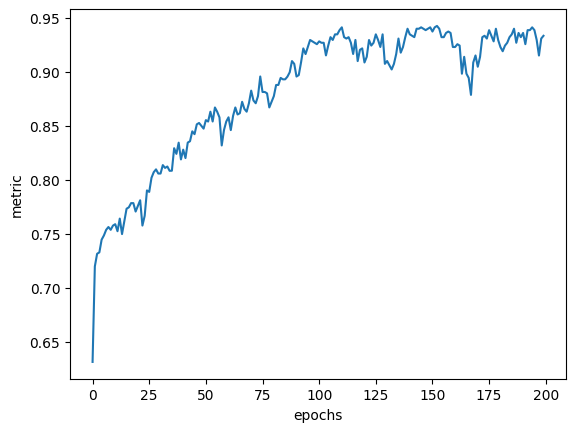

In [19]:
plot_history(history, "train_acc")

In [20]:
y_train_pred = model(torch_X_train.float()).argmax(-1)
y_test_pred = model(torch_X_test.float()).argmax(-1)

/home/steinb95/teaching/tud/physics/24/ml4ns/05_lecture/code/py312/lib64/python3.12/site-packages/torch/nn/modules/module.py:1736: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def plot_predictions(y_pred, y_true, title, labels=[0,1]):
    """ visualize a comparison of predicted versus true values """

    cm = confusion_matrix(y_true, y_pred, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=labels)
    disp.plot()
    plt.show()


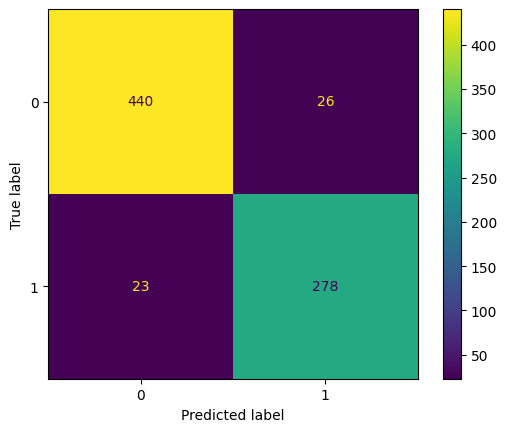

In [22]:
plot_predictions(y_train_pred.detach().numpy(),
                 y_train.to_numpy(),
                 title="predictions on the test set")

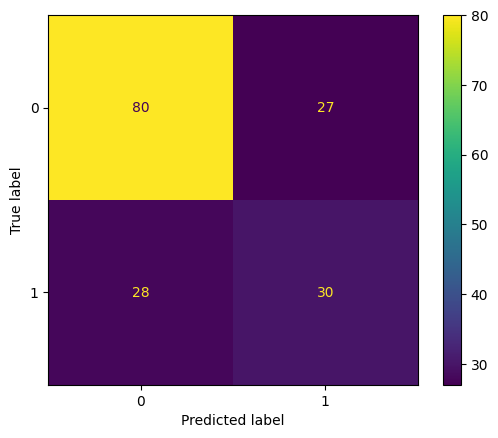

In [23]:
plot_predictions(y_test_pred.detach().numpy(),
                 y_test.to_numpy(),
                 title="predictions on the test set")

## Exercise: Record metrics on the validation set

Take the model training loop from above and add recording of metrics from the test set. As you will recall from the regression case, this will help you in judging if your model is overfitting or not. 

In [24]:
model2 = mlp_classification_model()
optimizer2 = torch.optim.Adam(model2.parameters())
loss_fn2 = torch.nn.CrossEntropyLoss()

In [25]:
torch_X_val = torch.from_numpy(X_val.to_numpy())
torch_y_val = torch.from_numpy(y_val.to_numpy())

stacked_val = torch.utils.data.StackDataset(X=torch_X_val, y=torch_y_val)
val_loader = torch.utils.data.DataLoader(stacked_val, batch_size = batch_size)

print(torch_X_val.shape, torch_y_val.shape)

torch.Size([164, 89]) torch.Size([164])


In [26]:
def train(model, crit, opt, train_loader, val_loader, batch_size=32,max_nepochs=200):

    nsteps = len(train_loader)
    nsteps_val = len(val_loader)
    train_loss, train_acc = torch.zeros((nsteps,)), torch.zeros((nsteps,))
    val_loss, val_acc = torch.zeros((nsteps_val,)), torch.zeros((nsteps_val,))
    
    history2 = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }
    
    for epoch in range(max_nepochs):
        start = time.time()
        model.train()
        for stepi, batch in enumerate(train_loader):
            
            # load data
            X, y = batch["X"].float(), batch["y"].float()
            
            # forward pass
            y_logit = model(X)
            
            # compute loss
            loss = crit(y_logit.float(), y.long().view(-1))
    
            # obtain index of highest probility class
            y_hat = torch.argmax(y_logit, dim=-1)
            accuracy = (y_hat.detach() == y.detach()).sum(dim=-1)/X.shape[0]
            
            # perform backprop
            loss.backward()
            # update weights
            opt.step()
            # set gradients to 0 for next step
            opt.zero_grad()
    
            train_loss[stepi] = loss.item()
            train_acc[stepi] = accuracy.item()
    
        end = time.time()
        delta_seconds = end - start
    
        history2["train_loss"].append(train_loss.mean().item())
        history2["train_acc" ].append(train_acc.mean().item())
        model.eval()
        with torch.no_grad():
            
            for vstepi, vbatch in enumerate(val_loader):
                val_X, val_y = vbatch["X"].float(), vbatch["y"].float()
                
                val_y_logit = model2(val_X)
                
                vloss = crit(val_y_logit.float(), val_y.long().view(-1))
                
                val_y_hat = torch.argmax(val_y_logit, dim=-1)
                vaccuracy = (val_y_hat.detach() == val_y.detach()).sum(dim=-1)/val_X.shape[0]
                
                val_loss[vstepi] = vloss.item()
                val_acc[vstepi] = vaccuracy.item()
    
            history2["val_loss"].append(val_loss.mean().item())
            history2["val_acc"].append(val_acc.mean().item())
            
        if (epoch+1) % 5 == 0:
            print(f"{epoch+1:03.0f}/{max_nepochs:03.0f}: {delta_seconds:02.4f} "
                  f"loss={train_loss.mean():03.4f} acc={train_acc.mean():03.4f} "
                  f"vloss={val_loss.mean():03.4f} vacc={val_acc.mean():03.4f} "
                  f"{delta_seconds*1000./(nsteps):3.1f} ms/step")

    return history2

In [27]:
history2 = train(model2, loss_fn2, optimizer2, train_loader, val_loader)

005/200: 0.0343 loss=0.5551 acc=0.7562 vloss=0.5484 vacc=0.7552 1.4 ms/step


/home/steinb95/teaching/tud/physics/24/ml4ns/05_lecture/code/py312/lib64/python3.12/site-packages/torch/nn/modules/module.py:1736: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


010/200: 0.0302 loss=0.5425 acc=0.7640 vloss=0.5466 vacc=0.7708 1.3 ms/step
015/200: 0.0290 loss=0.5303 acc=0.7771 vloss=0.5458 vacc=0.7708 1.2 ms/step
020/200: 0.0253 loss=0.5079 acc=0.8057 vloss=0.5513 vacc=0.7292 1.1 ms/step
025/200: 0.0252 loss=0.5049 acc=0.8083 vloss=0.5560 vacc=0.7292 1.0 ms/step
030/200: 0.0259 loss=0.4915 acc=0.8253 vloss=0.5624 vacc=0.7344 1.1 ms/step
035/200: 0.0463 loss=0.4858 acc=0.8292 vloss=0.5600 vacc=0.7292 1.9 ms/step
040/200: 0.0275 loss=0.4738 acc=0.8435 vloss=0.5764 vacc=0.7292 1.1 ms/step
045/200: 0.0292 loss=0.4733 acc=0.8371 vloss=0.5537 vacc=0.7344 1.2 ms/step
050/200: 0.0328 loss=0.5373 acc=0.7666 vloss=0.5738 vacc=0.7240 1.4 ms/step
055/200: 0.0261 loss=0.4721 acc=0.8436 vloss=0.5381 vacc=0.7760 1.1 ms/step
060/200: 0.0264 loss=0.4592 acc=0.8553 vloss=0.5367 vacc=0.7604 1.1 ms/step
065/200: 0.0261 loss=0.4586 acc=0.8579 vloss=0.5303 vacc=0.7708 1.1 ms/step
070/200: 0.0263 loss=0.4768 acc=0.8305 vloss=0.5169 vacc=0.8021 1.1 ms/step
075/200: 0.0

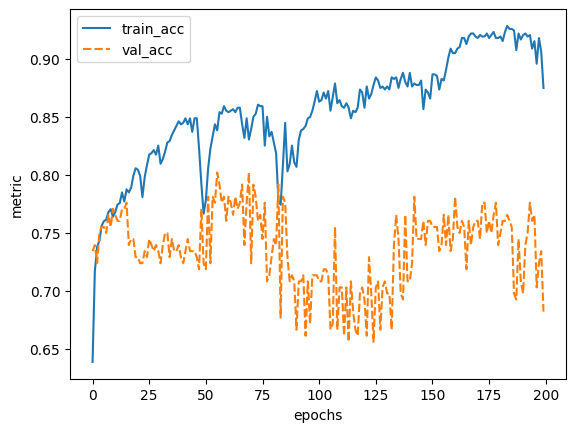

In [28]:
fig, ax = plot_history(history2, ["train_acc", "val_acc"])

The validation stops decreasing very early (around epoch 10). After that, the network apparently goes into **overfitting** (training loss decreases, validation loss is constant, fluctuates or increases). 

## Exercise: Try Regularisation

In the following, try at least one regularisation technique that you learned in the lecture. Check if the training behavior changes.

In [29]:
class dropout_classification_model(torch.nn.Module):

    def __init__(self, in_shape = X_data.shape[-1], num_classes=2, do_rate=.3):
        super().__init__()
        #for more complicated models, this constructor will be rather complicated
        self.hidden0 = torch.nn.Linear(in_features=in_shape, out_features=100)
        self.relu0 = torch.nn.ReLU()

        self.hidden1 = torch.nn.Linear(in_features=100, out_features=50)
        self.relu1 = torch.nn.ReLU()

        self.hidden2 = torch.nn.Linear(in_features=50, out_features=num_classes)
        
        self.outactivation = torch.nn.Softmax()
        self.dropout = torch.nn.Dropout(p=do_rate)

    def forward(self, x):
        """ forward pass of our model, using x as the input data. the output should be the prediction y_hat. """
        h0_out_ = self.hidden0(x)
        h0_out = self.relu0(h0_out_)
        
        h1_out_ = self.hidden1(h0_out)
        h1_out = self.relu1(h1_out_)

        output = self.dropout(h1_out)
        y_hat = self.hidden2(output)
        
        logit_output = self.outactivation(y_hat)
        
        return logit_output

In [30]:
model3 = dropout_classification_model(do_rate=0.1)
optimizer3 = torch.optim.Adam(model3.parameters())
loss_fn3 = torch.nn.CrossEntropyLoss()

In [31]:
batch_size=32
nepochs=100
train_loader = torch.utils.data.DataLoader(stacked_train, batch_size = batch_size)
val_loader = torch.utils.data.DataLoader(stacked_val, batch_size = batch_size)

history3 = train(model3, loss_fn3, optimizer3, train_loader, val_loader, batch_size=batch_size, max_nepochs=nepochs)

/home/steinb95/teaching/tud/physics/24/ml4ns/05_lecture/code/py312/lib64/python3.12/site-packages/torch/nn/modules/module.py:1736: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


005/100: 0.0287 loss=0.5667 acc=0.7327 vloss=0.5982 vacc=0.6823 1.2 ms/step
010/100: 0.0311 loss=0.5569 acc=0.7484 vloss=0.5982 vacc=0.6823 1.3 ms/step
015/100: 0.0307 loss=0.5411 acc=0.7680 vloss=0.5982 vacc=0.6823 1.3 ms/step
020/100: 0.0265 loss=0.5296 acc=0.7811 vloss=0.5982 vacc=0.6823 1.1 ms/step
025/100: 0.0278 loss=0.5214 acc=0.7862 vloss=0.5982 vacc=0.6823 1.2 ms/step
030/100: 0.0276 loss=0.5057 acc=0.8045 vloss=0.5982 vacc=0.6823 1.1 ms/step
035/100: 0.0366 loss=0.4938 acc=0.8227 vloss=0.5982 vacc=0.6823 1.5 ms/step
040/100: 0.0275 loss=0.4808 acc=0.8409 vloss=0.5982 vacc=0.6823 1.1 ms/step
045/100: 0.0302 loss=0.4743 acc=0.8369 vloss=0.5982 vacc=0.6823 1.3 ms/step
050/100: 0.0280 loss=0.4779 acc=0.8345 vloss=0.5982 vacc=0.6823 1.2 ms/step
055/100: 0.0284 loss=0.4600 acc=0.8592 vloss=0.5982 vacc=0.6823 1.2 ms/step
060/100: 0.0284 loss=0.4503 acc=0.8643 vloss=0.5982 vacc=0.6823 1.2 ms/step
065/100: 0.0280 loss=0.4508 acc=0.8670 vloss=0.5982 vacc=0.6823 1.2 ms/step
070/100: 0.0

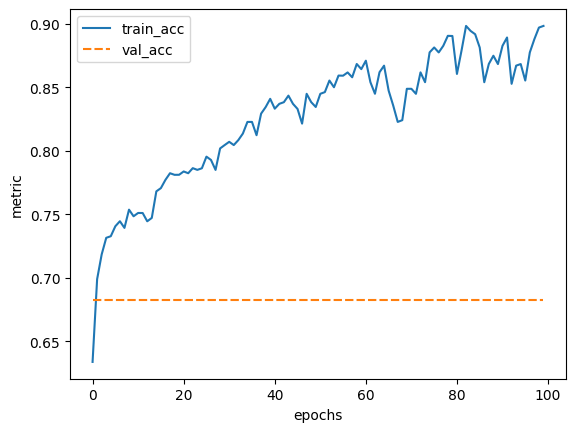

In [32]:
fig, ax = plot_history(history3, ["train_acc", "val_acc"])